<a href="https://colab.research.google.com/github/Otza02/satellite-img-segmentation/blob/main/notebooks/train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Otza02/satellite-img-segmentation.git
%cd satellite-img-segmentation
!pip install -e .

Cloning into 'satellite-img-segmentation'...
remote: Enumerating objects: 111, done.
remote: Counting objects: 100% (111/111), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 111 (delta 44), reused 91 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (111/111), 833.32 KiB | 19.38 MiB/s, done.
Resolving deltas: 100% (44/44), done.
/content/satellite-img-segmentation
Obtaining file:///content/satellite-img-segmentation
  Preparing metadata (setup.py) ... done
  Running setup.py develop for satelliteSegmentation


## -- Reiniciar session --

In [2]:
%cd /content/satellite-img-segmentation
!unzip data/processed.zip -d data/processed

Streaming output truncated to the last 5000 lines.
 extracting: data/processed/train/masks_id/tile_1.3_31.png  
 extracting: data/processed/train/masks_id/tile_1.3_32.png  
 extracting: data/processed/train/masks_id/tile_1.3_33.png  
 extracting: data/processed/train/masks_id/tile_1.3_34.png  
  inflating: data/processed/train/masks_id/tile_1.3_35.png  
  inflating: data/processed/train/masks_id/tile_1.3_36.png  
 extracting: data/processed/train/masks_id/tile_1.3_37.png  
 extracting: data/processed/train/masks_id/tile_1.3_38.png  
 extracting: data/processed/train/masks_id/tile_1.3_39.png  
 extracting: data/processed/train/masks_id/tile_1.3_4.png  
 extracting: data/processed/train/masks_id/tile_1.3_40.png  
 extracting: data/processed/train/masks_id/tile_1.3_41.png  
 extracting: data/processed/train/masks_id/tile_1.3_42.png  
 extracting: data/processed/train/masks_id/tile_1.3_43.png  
  inflating: data/processed/train/masks_id/tile_1.3_44.png  
  inflating: data/processed/train/m

In [3]:
from satelliteSegmentation.config import Config
from satelliteSegmentation.dataset import load_data, SatelliteData
from satelliteSegmentation.models.unet import UNet
from satelliteSegmentation.utils import train_model, run_one_epoch

import torch
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader

In [4]:
data_train = load_data("val")
data_val = load_data("test")

100%|██████████| 648/648 [00:01<00:00, 425.01it/s]


Dataset cargado:
X shape = torch.Size([648, 3, 120, 120])
Y shape = torch.Size([648, 120, 120])


100%|██████████| 648/648 [00:00<00:00, 687.84it/s]


Dataset cargado:
X shape = torch.Size([648, 3, 120, 120])
Y shape = torch.Size([648, 120, 120])


In [5]:
conf = Config("cuda" if torch.cuda.is_available() else "cpu", epochs=8)
conf

Config(device='cuda', batch_size=128, kernel_size=3, stride=1, in_channels=3, hidden_channels=(64, 128, 256, 512), bottleneck_channels=1024, num_classes=7, epochs=8, lr=0.0001, patience=5, min_delta=0.001)

In [6]:
model = UNet(conf)
f"{sum([p.numel() for p in model.parameters()]):,}"

'31,043,911'

In [7]:
# train_loader = DataLoader(data_train, batch_size=conf.batch_size, shuffle=True)
# val_loader = DataLoader(data_val, batch_size=conf.batch_size, shuffle=False)
train_loader = DataLoader(
    data_train,
    batch_size=conf.batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=conf.device == "cuda",
    persistent_workers=conf.device == "cuda",
)

val_loader = DataLoader(
    data_val,
    batch_size=conf.batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=conf.device == "cuda",
    persistent_workers=conf.device == "cuda",
)


model, history = train_model(model, train_loader, val_loader, conf)

Epoch 01/8 | train_loss=1.7784 | val_loss=1.9163 | time 00:06
Epoch 02/8 | train_loss=1.4699 | val_loss=1.8968 | time 00:04
Epoch 03/8 | train_loss=1.2420 | val_loss=1.8627 | time 00:04
Epoch 04/8 | train_loss=1.0992 | val_loss=1.7738 | time 00:04
Epoch 05/8 | train_loss=0.9990 | val_loss=1.6286 | time 00:04
Epoch 06/8 | train_loss=0.9446 | val_loss=1.4397 | time 00:04
Epoch 07/8 | train_loss=0.9401 | val_loss=1.2115 | time 00:04
Epoch 08/8 | train_loss=0.8222 | val_loss=1.0426 | time 00:04


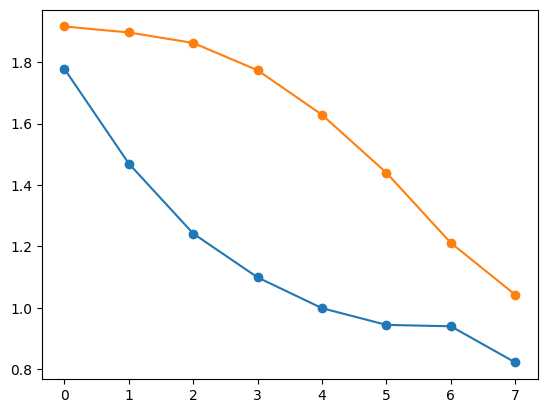

In [11]:
plt.plot(history["train_loss"], label="train_loss", marker="o")
plt.plot(history["val_loss"], label="val_loss", marker="o")